In [29]:
import pandas as pd 
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [6]:
df.head()

,society,price,sector,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,property_type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,independent,15.50,sector 43,28233.0,5,6,3,3.0,Moderately Old,house,5490.00,1,1,1,1,0,0,76
1,trisara our homes 3,0.38,sohna road,6312.0,2,2,2,1.0,Relatively New,flat,602.00,0,0,0,0,0,0,0
2,sare green parc phase 3,0.70,sector 92,5279.0,3,2,2,4.0,Relatively New,flat,1325.00,0,0,0,0,0,0,56
3,emaar gurgaon greens,1.60,sector 102,9696.0,3,3,3,8.0,Relatively New,flat,1315.00,0,0,0,0,0,0,46
4,emaar mgf the palm drive,3.98,sector 66,18090.0,3,4,3+,2.0,Moderately Old,flat,2200.11,0,1,0,0,0,2,123


In [7]:
latlong= pd.read_csv('latlong.csv')

In [8]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')

In [9]:
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [10]:
latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [11]:
new_df = df.merge(latlong, on='sector')

In [12]:
new_df.head()

,society,price,sector,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,property_type,...,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,coordinates,latitude,longitude
0,independent,15.50,sector 43,28233.0,5,6,3,3.0,Moderately Old,house,...,1,1,1,1,0,0,76,"28.4629° N, 77.0772° E",28.4629,77.0772
1,sare green parc phase 3,0.70,sector 92,5279.0,3,2,2,4.0,Relatively New,flat,...,0,0,0,0,0,0,56,"28.4079° N, 76.9153° E",28.4079,76.9153
2,emaar gurgaon greens,1.60,sector 102,9696.0,3,3,3,8.0,Relatively New,flat,...,0,0,0,0,0,0,46,"28.4750° N, 76.9715° E",28.4750,76.9715
3,emaar mgf the palm drive,3.98,sector 66,18090.0,3,4,3+,2.0,Moderately Old,flat,...,0,1,0,0,0,2,123,"28.3925° N, 77.0541° E",28.3925,77.0541
4,ireo the corridors,1.40,sector 67a,9433.0,2,2,2,8.0,Relatively New,flat,...,1,0,0,0,1,0,90,"28.3960° N, 77.0372° E",28.3960,77.0372


In [13]:
group_df = new_df.groupby('sector')[[
    'price',
    'price_per_sqft',
    'built_up_area',
    'latitude',
    'longitude'
]].mean()

In [14]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.888889,3056.166667,28.4484,77.0210
manesar,0.962258,4608.000000,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.500000,2327.833333,28.3663,76.9456
sector 102,1.696636,10603.719626,1556.130841,28.4750,76.9715
sector 103,1.503415,7437.682927,1880.439024,28.4949,76.9845
...,...,...,...,...,...
sector 92,0.936000,5939.700000,1571.241800,28.4079,76.9153
sector 93,0.848889,8010.666667,1017.000000,28.4153,76.9326
sector 95,0.482037,5561.629630,1003.851852,28.4172,76.9081


C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_22568\860414701.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',


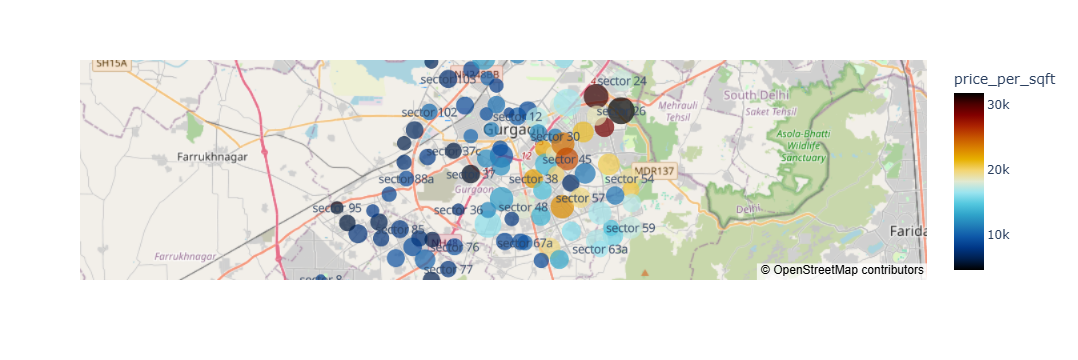

In [15]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

In [16]:
new_df.to_csv('data_viz.csv',index=False)


In [17]:
df1 = pd.read_csv('gurgaon_properties.csv')

In [18]:
df1.head()

,property_name,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,property_type
0,5 Bedroom House for sale in B Block Sushant Lo...,independent,15.50,28233.0,5490.00,Plot area 610(510.04 sq.m.),5,6,3,"pooja room,study room,servant room,store room","B Block Sushant Lok Phase 1, Gurgaon, Haryana",3.0,East,5 to 10 Year Old,"['Iffco chowk metro station', 'Huda city centr...","Basement , ground floor, first floor and terra...",[],"['Private Garden / Terrace', 'Water purifier',...","['Environment4 out of 5', 'Lifestyle4.5 out of...",house
1,2 BHK Flat in Sohna,trisara our homes 3,0.38,6312.0,602.03,Built Up area: 602 (55.93 sq.m.),2,2,2,not availaible,"Sohna Sector 6, Sohna, Gurgaon, Haryana",1st of 1 Floors,NaN,undefined,"['Metro Station', 'Gyanchand Market', 'Rajiv C...",Best in class property available at sector 6 s...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,"['Environment4 out of 5', 'Safety4 out of 5', ...",NaN
2,3 BHK Flat in Sector 92 Gurgaon,sare green parc phase 3,0.70,5279.0,1326.01,Super Built up area 1326(123.19 sq.m.)Built Up...,3,2,2,not availaible,"Sector 92 Gurgaon, Gurgaon, Haryana",4th of 19 Floors,NaN,1 to 5 Year Old,"['Huda Metro Station', 'Sector Road', 'Delhi-J...",Property at 4th floor ne facing,"['2 Wardrobe', '4 Fan', '1 Exhaust Fan', '2 Ge...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment5 out of 5', 'Lifestyle4 out of 5...",NaN
3,3 BHK Flat in Sector 102 Gurgaon,emaar gurgaon greens,1.60,9696.0,1650.17,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,not availaible,"Sector 102 Gurgaon, Gurgaon, Haryana",8th of 14 Floors,NaN,1 to 5 Year Old,"['JMS Marine Square Mall', 'Dwarka Expressway'...","Situated in sector 102 gurgaon, emaar gurgaon ...",[],"['Power Back-up', 'Intercom Facility', 'Lift(s...","['Green Area5 out of 5', 'Construction4 out of...",NaN
4,3 BHK Flat in Sector 66 Gurgaon,emaar mgf the palm drive,3.98,18090.0,2200.11,Super Built up area 2200(204.39 sq.m.),3,4,3+,servant room,"Sector 66 Gurgaon, Gurgaon, Haryana",2nd of 17 Floors,South-East,5 to 10 Year Old,"['Sector 55-56 Rapid Metro Station', 'HUB 66',...","Beautiful two side open property, facing kids ...","['6 Wardrobe', '5 Fan', '1 Exhaust Fan', '4 Ge...","['Security / Fire Alarm', 'Power Back-up', 'In...","['Green Area5 out of 5', 'Construction4.5 out ...",NaN


In [19]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [51]:
wordcloud_df.head()

,features,sector
0,"['Private Garden / Terrace', 'Water purifier',...",sector 43
1,NaN,sohna road
2,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 92
3,"['Power Back-up', 'Intercom Facility', 'Lift(s...",sector 102
4,"['Security / Fire Alarm', 'Power Back-up', 'In...",sector 66


In [54]:
wordcloud_df.to_csv('wordcloud_df.csv', index = False)

In [21]:
import ast
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [47]:
sector = wordcloud_df[wordcloud_df.sector == 'sector 92']

In [48]:
sector

,features,sector
2,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 92
30,"['Centrally Air Conditioned', 'Water purifier'...",sector 92
135,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 92
177,"['Centrally Air Conditioned', 'Water purifier'...",sector 92
208,"['Security / Fire Alarm', 'Power Back-up', 'Fe...",sector 92
...,...,...
3379,"['Centrally Air Conditioned', 'Water purifier'...",sector 92
3388,"['Feng Shui / Vaastu Compliant', 'Private Gard...",sector 92
3407,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 92
3464,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 92


In [49]:
from ast import literal_eval

feature_list = []

for item in sector['features'].dropna():
    feature_list.extend(literal_eval(item))

feature_text = " ".join(feature_list)

In [50]:
feature_text

'Feng Shui / Vaastu Compliant Security / Fire Alarm Intercom Facility Lift(s) Maintenance Staff Water Storage Park Visitor Parking Club house / Community Center Rain Water Harvesting Centrally Air Conditioned Water purifier Security / Fire Alarm Feng Shui / Vaastu Compliant Intercom Facility Lift(s) High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage Separate entry for servant room No open drainage around Piped-gas Internet/wi-fi connectivity Recently Renovated Visitor Parking Swimming Pool Park Natural Light Airy Rooms Spacious Interiors Waste Disposal Rain Water Harvesting Water softening plant Shopping Centre Fitness Centre / GYM Club house / Community Center Feng Shui / Vaastu Compliant Security / Fire Alarm Intercom Facility Lift(s) Maintenance Staff Water Storage Park Visitor Parking Centrally Air Conditioned Water purifier Security / Fire Alarm Feng Shui / Vaastu Compliant Intercom Facility Lift(s) High Ceiling Height Maintenance Staff Water Storage Separa

In [22]:
main

['Private Garden / Terrace',
 'Water purifier',
 'False Ceiling Lighting',
 'Water Storage',
 'Natural Light',
 'Internet/wi-fi connectivity',
 'Airy Rooms',
 'Spacious Interiors',
 'Fitness Centre / GYM',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Feng Shui / Vaastu Compliant',
 'Security / Fire Alarm',
 'Intercom Facility',
 'Lift(s)',
 'Maintenance Staff',
 'Water Storage',
 'Park',
 'Visitor Parking',
 'Club house / Community Center',
 'Rain Water Harvesting',
 'Power Back-up',
 'Intercom Facility',
 'Lift(s)',
 'Swimming Pool',
 'Maintenance Staff',
 'Park',
 'Security Personnel',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Security / Fire Alarm',
 'Power Back-up',
 'Intercom Facility',
 'Lift(s)',
 'High Ceiling Height',
 'Maintenance Staff',
 'Water Storage',
 'No open drainage around',
 'Recently Renovated',
 'Bank Attached Property',
 'Piped-gas',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Natural Light',
 'Airy Rooms',
 'Spaci

In [27]:
from wordcloud import WordCloud

In [24]:
feature_text = ' '.join(main)

In [25]:
import pickle
pickle.dump(feature_text, open('feature_text.pkl','wb'))

In [26]:
feature_text

'Private Garden / Terrace Water purifier False Ceiling Lighting Water Storage Natural Light Internet/wi-fi connectivity Airy Rooms Spacious Interiors Fitness Centre / GYM Waste Disposal Rain Water Harvesting Feng Shui / Vaastu Compliant Security / Fire Alarm Intercom Facility Lift(s) Maintenance Staff Water Storage Park Visitor Parking Club house / Community Center Rain Water Harvesting Power Back-up Intercom Facility Lift(s) Swimming Pool Maintenance Staff Park Security Personnel Fitness Centre / GYM Club house / Community Center Security / Fire Alarm Power Back-up Intercom Facility Lift(s) High Ceiling Height Maintenance Staff Water Storage No open drainage around Recently Renovated Bank Attached Property Piped-gas Visitor Parking Swimming Pool Park Security Personnel Natural Light Airy Rooms Spacious Interiors Low Density Society Shopping Centre Fitness Centre / GYM Waste Disposal Rain Water Harvesting Club house / Community Center Security / Fire Alarm Intercom Facility Lift(s) Hig

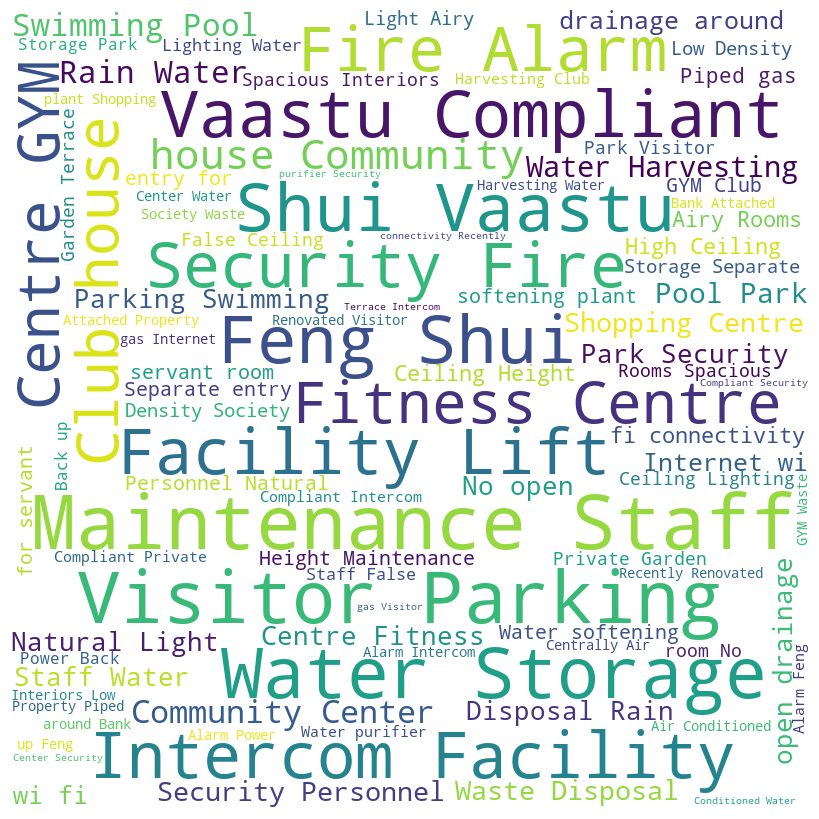

In [30]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() # st.pyplot()

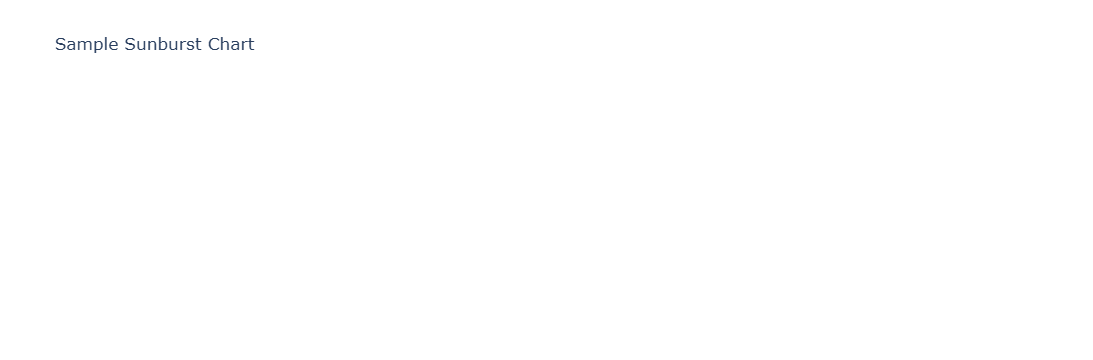

In [31]:
data = dict(
    names=["A", "B", "C", "D", "E", "F"],
    parents=["", "", "", "A", "A", "C"],
    values=[10, 20, 30, 40, 50, 60],
)

fig = px.sunburst(
    df1,
    names='property_type',
    values='price_per_sqft',
    parents='bedRoom',
    title="Sample Sunburst Chart"
)
fig.show()

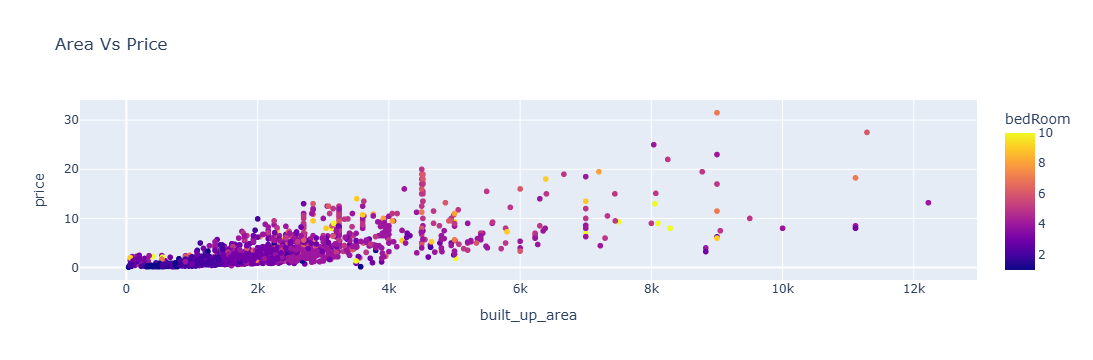

In [32]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

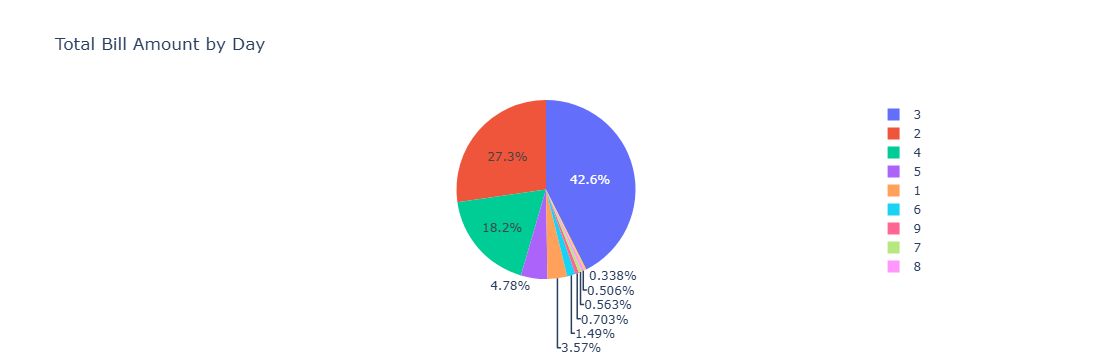

In [33]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

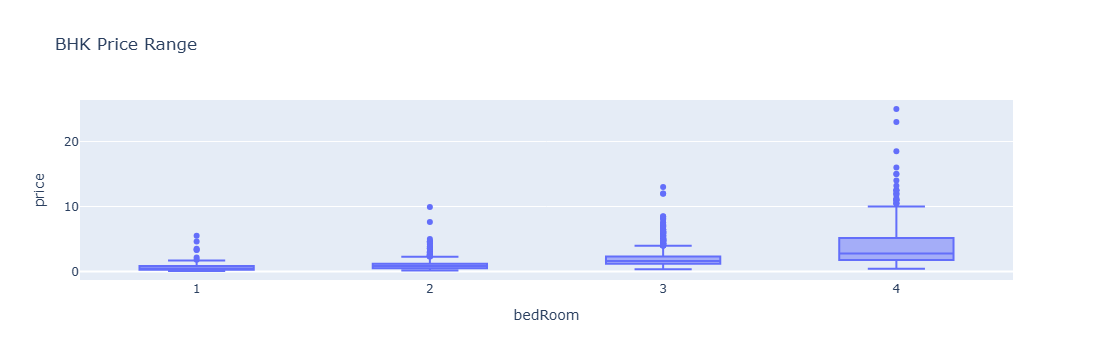

In [34]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()